In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Contours



Edges of objects in the image

- used to detect objects, shape, and measure their size
- work on binary images because it provides sharp edges

findContours(): 

find the edges, take 3 arguments

- Source Image: image from which we want to find the contours
- Contour Retrieval Mode: This determines how contours are retrieved
 - - 1.	Retrieve External: output only the external contours
 - - 2.	Retrieve List: output all contours without any hierarchical relationship
 - - 3.	Retrieve Tree: output all contours with hierarchical relationship


Contour Approximation Method: 

This decides how much detail to keep when storing the contours
- - 1.	CHAIN_APPROX_NONE: all points are stored, no compression
- - 2.	CHAIN_APPROX_SIMPLE: store some points in straight objects like rectangle need 4 points
- - 3.	CHAIN_APPROX_TCB89_L1
- - 4.	CHAIN_APPROX_TCB89_COS


Output

The function gives us three outputs:

- Image: The image with contours found in it
- Contours: A list of contours. Each contour is made up of the (x, y) coordinates that outline a shape in the image
- Hierarchy: This gives extra information about the contours like which ones are inside others

drawContours()

Draw the contours on original image to visualize the image

Number of contours found: 11


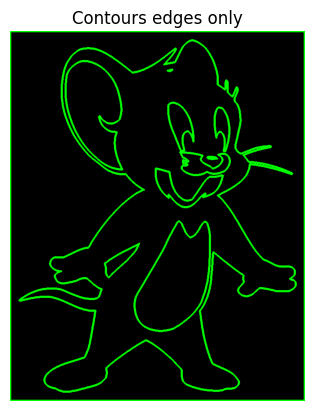

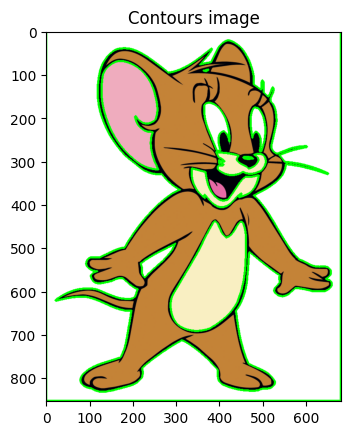

In [17]:
#contours
img_jerry=cv.imread('H:/OpenCV-Mastery-Roadmap/images/jerry.png')
gray_for_contours = cv.cvtColor(img_jerry, cv.COLOR_BGR2GRAY)
binary_for_contours = cv.threshold(gray_for_contours, 0, 255, cv.THRESH_BINARY+cv.THRESH_OTSU)

#cv.findContours(image, mode, method)
contours, hierarchy = cv.findContours(binary_for_contours[1], cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
print(f'Number of contours found: {len(contours)}')

# draw contours on the original image
# cv.drawContours(image, contours, contourIdx, color, thickness)
jerry_with_contours=cv.drawContours(img_jerry, contours, -1, (0,255,0), 3)

# show the image with contours in matplotlib
# show only contour edges on a black background
edges_only = np.zeros_like(img_jerry) # create a black image with the same shape as the original
edges_only = cv.drawContours(edges_only, contours, -1, (0,255,0), 3)
plt.imshow(cv.cvtColor(edges_only, cv.COLOR_BGR2RGB))
plt.title('Contours edges only')
plt.axis('off')
plt.show()

plt.imshow(cv.cvtColor(jerry_with_contours, cv.COLOR_BGR2RGB))
plt.title('Contours image')
plt.show()



# cv.imshow('Contours', jerry_with_contours)
# cv.imshow('Gray', gray_for_contours)
# cv.imshow('Binary', binary_for_contours[1])
# cv.waitKey(0)
# cv.destroyAllWindows()


# Histograms

A graph that shows the frequency distribution of data. It group the data into bins 

- Frequency: number of pixels for each intensity value(bin)
- Bins: show the intensity for each intensity value from 0 to 255
- Brightness: Average intensity of all pixels
- Contrast: brightness difference between light & dark areas of image (important for photography)




## Histogram Equalization

 a basic image processing technique that can improve an image’s overall contrast

 It stretches the histogram to improve the image contrast

 If the contrast is too low, it is impossible to distinguish between two objects

 Basically image occupy all possible intensity levels from 0-255 which were not in low constrast

## 1. Global Histogram Equalization (GHE)

It applies a single transformation function to the entire image

It often fails when images have large intensity variations (e.g., very bright and very dark areas) 

### Gray Histogram

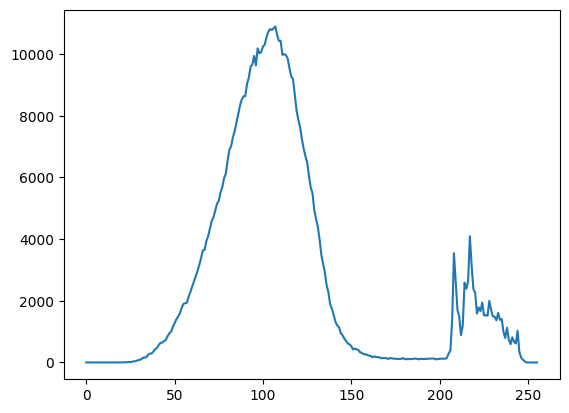

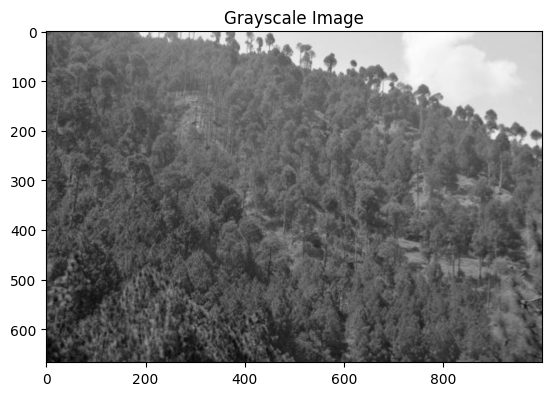

In [29]:
# calculate histogram 
forest = cv.imread('../images/forest.jpg')
gray_forest = cv.cvtColor(forest, cv.COLOR_BGR2GRAY)

#        cv.calcHist(images, channels, mask, histSize, ranges) # pass values as tuple
hist = cv.calcHist([gray_forest], [0], None, [256], [0, 256])
plt.plot(hist)
plt.show()  

plt.imshow(gray_forest, cmap='gray')
plt.title('Grayscale Image')
plt.show()

#### Equalize the Gray Histogram

cv.equalizeHist()

It equalize the image by normalizing the brightness and increasing the contrast 

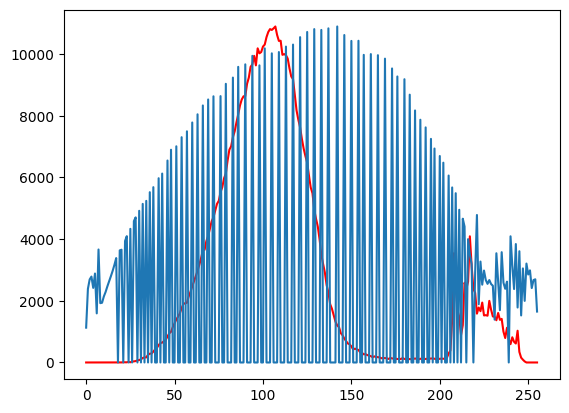

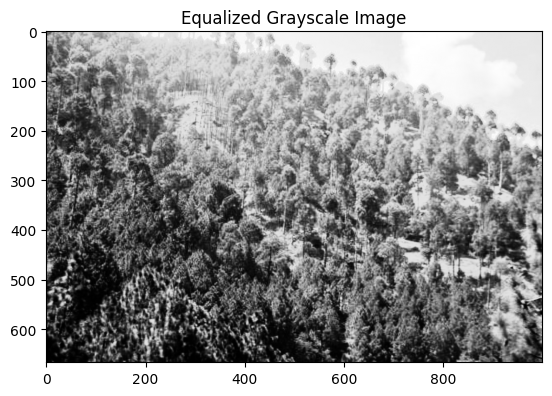

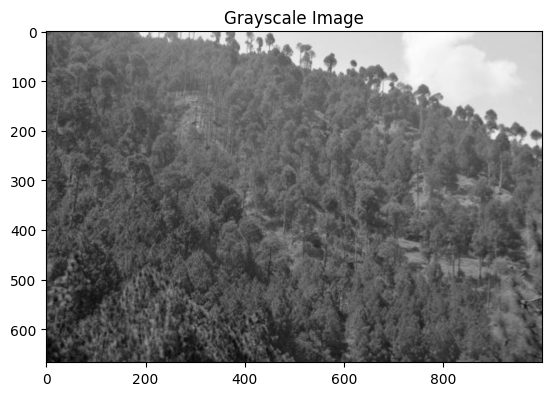

In [19]:
# calculate histogram 
forest = cv.imread('../images/forest.jpg')
gray_forest = cv.cvtColor(forest, cv.COLOR_BGR2GRAY)

#        cv.calcHist(images, channels, mask, histSize, ranges) # pass values as tuple
hist_gray = cv.calcHist([gray_forest], [0], None, [256], [0, 256])
plt.plot(hist_gray, color='red')
equalize_hist_gray = cv.equalizeHist(gray_forest)
hist_gray = cv.calcHist([equalize_hist_gray], [0], None, [256], [0, 256])
plt.plot(hist_gray)
plt.show()  
    
plt.imshow(equalize_hist_gray, cmap='gray')
plt.title('Equalized Grayscale Image')
plt.show()
plt.imshow(gray_forest, cmap='gray')
plt.title('Grayscale Image')
plt.show()

### Colored Histogram

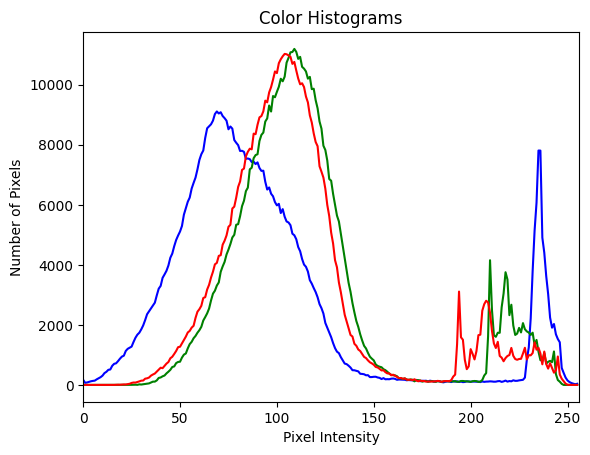

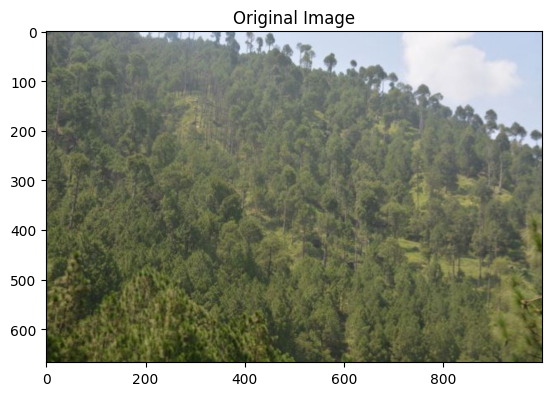

In [ ]:
# color histogram
forest = cv.imread('../images/forest.jpg')
b,g,r= cv.split(forest)

# calculate histogram for each channel 
#cv.calcHist(images, channels, mask, histSize, ranges) # pass values as tuple
hist_b = cv.calcHist([b], [0], None, [256], [0, 256])
hist_g = cv.calcHist([g], [0], None, [256], [0, 256])
hist_r = cv.calcHist([r], [0], None, [256], [0, 256])
# plot the histograms
plt.plot(hist_b, color='blue')
plt.plot(hist_g, color='green')
plt.plot(hist_r, color='red')
plt.title('Color Histograms')
plt.xlabel('Pixel Intensity')
plt.ylabel('Number of Pixels')
plt.xlim([0, 256])
plt.show()



cv.imshow("Original Image", forest)
cv.waitKey(0)
cv.destroyAllWindows()



#### Equalize Colored Histogram

To equalized a color image, it is better to use HSV color space instead of BGR

It is because they store information and light information separately

Other color spaces can also be used 

-   YCrCb


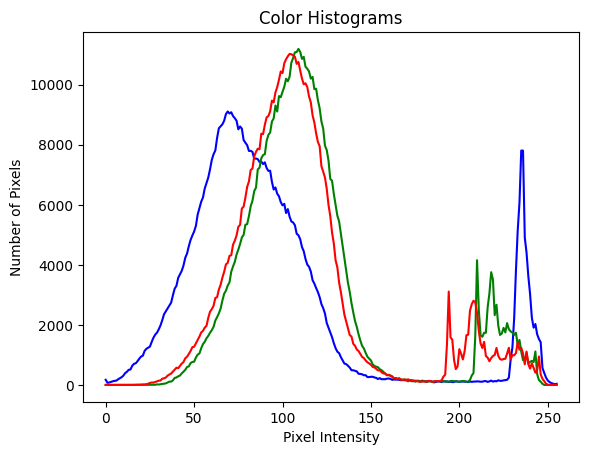

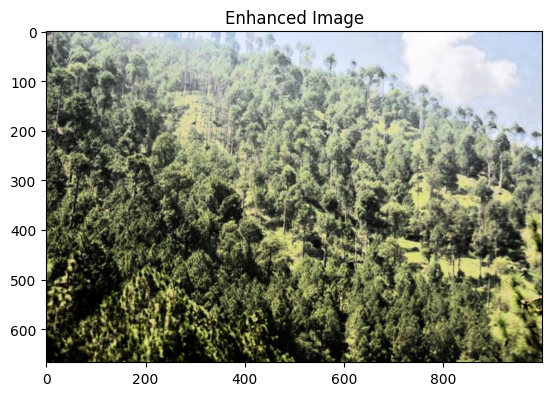

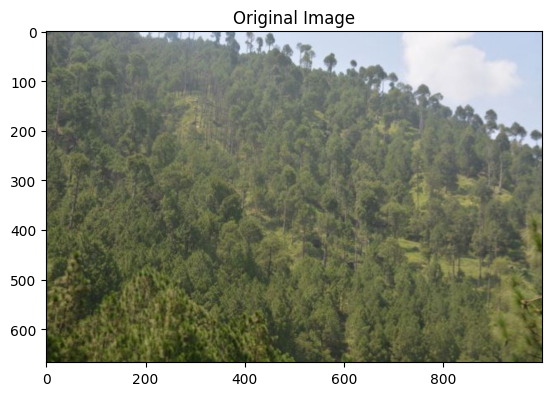

In [ ]:
# color histogram
forest = cv.imread('../images/forest.jpg')
b,g,r= cv.split(forest)

# calculate histogram for each channel # pass values as tuple
hist_b = cv.calcHist([b], [0], None, [256], [0, 256])
hist_g = cv.calcHist([g], [0], None, [256], [0, 256])
hist_r = cv.calcHist([r], [0], None, [256], [0, 256])

# convert to hsv
hsv_forest = cv.cvtColor(forest, cv.COLOR_BGR2HSV)
h,s,v = cv.split(hsv_forest)
# equalize the V channel
v= cv.equalizeHist(v)
# merge back the channels and convert to bgr
hsv_forest_equalized = cv.merge((h,s,v))
bgr_enhanced = cv.cvtColor(hsv_forest_equalized, cv.COLOR_HSV2BGR)


# plot the histograms
plt.plot(hist_b, color='blue')
plt.plot(hist_g, color='green')
plt.plot(hist_r, color='red')
plt.title('Color Histograms')
plt.xlabel('Pixel Intensity')
plt.ylabel('Number of Pixels')
plt.show()

# enhance the image using histogram equalization on the V channel of the HSV color space
plt.imshow(cv.cvtColor(bgr_enhanced, cv.COLOR_BGR2RGB))
plt.title('Enhanced Image')
plt.show()

# show the original image for comparison
plt.imshow(cv.cvtColor(forest, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.show()

cv.imshow("Original Image", forest)
cv.imshow("Enhanced Image", bgr_enhanced)
cv.waitKey(0)
cv.destroyAllWindows()



## 2.   Adaptive Histogram Equalization (AHE)

It divede the image into smaller parts called tiles then apply HE on each part

Pros: It is better option than GHE for edge detection

Cons: it over-amplifys noise in homogenous regions like grains

createCLAHE()

2 parameters

- clipLimit: sets the threshold for contrast limiting. For AHE, its value is high like 40+ 
- tileGridSize: divide the image into grids(tiles) for applying CLAHE. It sets the number of rows and columns. Default value is 8x8.

In [ ]:
# calculate AHE (Adaptive Histogram Equalization)
forest = cv.imread('../images/forest.jpg')
gray_forest = cv.cvtColor(forest, cv.COLOR_BGR2GRAY)

# clahe (Threshold of contrast limited adaptive histogram equalization)
ahe_clahe = cv.createCLAHE(clipLimit=40.0, tileGridSize=(8,8))
ahe_forest = ahe_clahe.apply(gray_forest)

# show the clahe images
plt.imshow(ahe_forest, cmap='gray')
plt.title('Grayscale Image with AHE')
plt.show()

## 3.    Contrast Limited Adaptive Histogram Equalization (CLAHE)

CLAHE improves contrast without increasing noise (that sometimes created in AHE)

- It divede the image into smaller parts then apply AHE on each part

- It limit the contrast enhancement by clipping the histogram

- It avoid the image from getting too dark or too light
- Best for general photography and medical imaging

createCLAHE(): use the same function but lower the clipLimit like 5

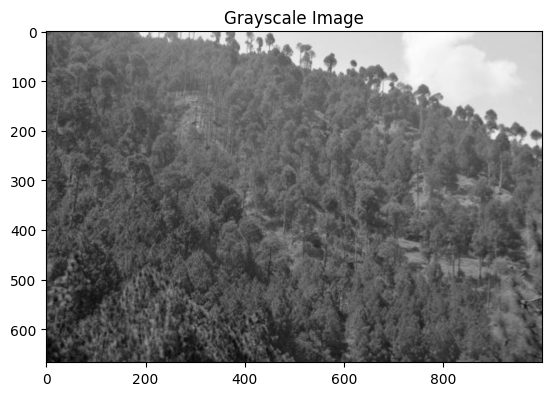

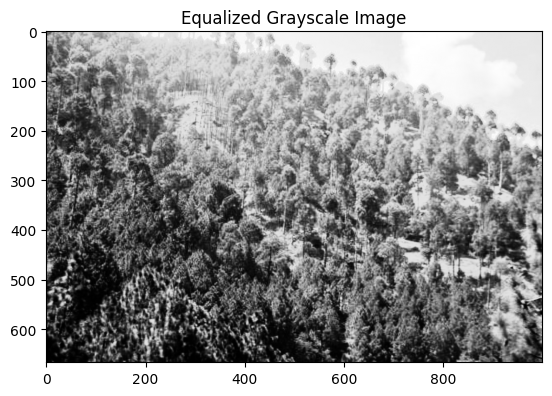

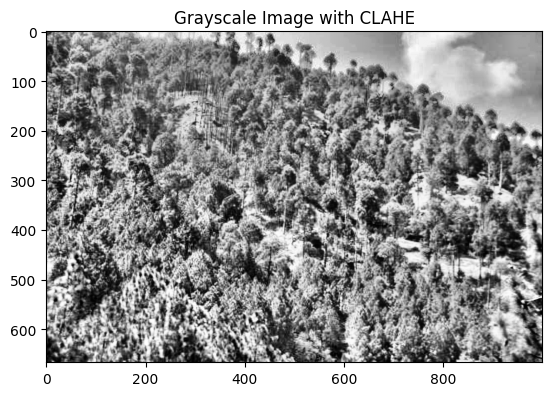

In [36]:
# calculate histogram 
forest = cv.imread('../images/forest.jpg')
gray_forest = cv.cvtColor(forest, cv.COLOR_BGR2GRAY)

# clahe (Threshold of contrast limited adaptive histogram equalization)
clahe = cv.createCLAHE(clipLimit=5.0)
clahe_forest = clahe.apply(gray_forest)


# show gray scale image
plt.imshow(gray_forest, cmap='gray')
plt.title('Grayscale Image')
plt.show()

# show the equalized image
equalize_hist_gray = cv.equalizeHist(gray_forest)
plt.imshow(equalize_hist_gray, cmap='gray')
plt.title('Equalized Grayscale Image')
plt.show()

# show the clahe images
plt.imshow(clahe_forest, cmap='gray')
plt.title('Grayscale Image with CLAHE')
plt.show()



# Webcam/Video

### Reading Webcam Video

cv2.VideoCapture()

Creates a video capture object to display the video
It can take video feed from 
- Webcamp
- Video File
- IP Camera

Member Functions
- get()
- set()
- read()
- isOpened()

In [ ]:
# capture webcam
cap = cv.VideoCapture(0)
# indicator 
if not cap.isOpened():
    raise RuntimeError("Could not open webcam")

while True:
    ret, frame = cap.read()
    if not ret:
        break             
    else:
        # show in player
        cv.imshow('Webcam', frame)
        if cv.waitKey(2)==27: # press 'Esc' to exit
            break
        
# release resources
cap.release()
cv.destroyAllWindows()

#### Change color of Video

In [ ]:
# webcam
cap = cv.VideoCapture(0)
# indicator 
if not cap.isOpened():
    raise RuntimeError("Could not open webcam")

while True:
    ret, frame = cap.read()
    if not ret:
        break             
    else: 
        # convert to grayscale
        gray_frame = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
        # show in player
        cv.imshow('Webcam Gray', gray_frame)
        if cv.waitKey(2)==27: # press 'Esc' to exit
            break
        
# release resources
cap.release()
cv.destroyAllWindows()

#### Frames Per Second (FPS)

cap.get() 

method to read the video metadata such as frame height, width, fps

In [ ]:
# FPS (Frames Per Second)
cap = cv.VideoCapture(0)
# cv.get() get properties of the video capture
height= cap.get(cv.CAP_PROP_FRAME_HEIGHT)
width= cap.get(cv.CAP_PROP_FRAME_WIDTH)
fps= cap.get(cv.CAP_PROP_FPS)
print(f'Webcam resolution: {width}x{height}, FPS: {fps}')

if not cap.isOpened():
    raise RuntimeError("Could not open webcam")
while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    
    cv.imshow('Webcam', frame)
    
    if cv.waitKey(2)==27: # press 'Esc' to exit
        break

cap.release()
cv.destroyAllWindows()

Webcam resolution: 640.0x480.0, FPS: 30.0


### Reading Video from Video File

To read an existing video, we need its filename

cv.VideoCapture('filename')

waitKey(n)

We can control the speed of video through waitKey

- High value--> slow video 
- Low value--> fast video


In [ ]:
# capture video object
cap = cv.VideoCapture('../images/study.mp4')
# indicator 
if not cap.isOpened():
    raise RuntimeError("Could not open video file")

while True:
    ret, frame = cap.read()
    if not ret:
        break             
    else:
        # show in player
        cv.imshow('Video Read', frame)
        # waitKey() increase or decrease the speed of the video
        if cv.waitKey(1)==27: # press 'Esc' to exit
            break
        
# release resources
cap.release()
cv.destroyAllWindows()

### Writing Video from Webcam

cv.VideoWriter() 

Create the Videowrite object 

4 parameters
- finename
- four character code of codec like DIVX, XVID, X264,  MJPG
- fps
- framesize

Member Function
write()

Write the video frames to save

In [ ]:
# Video Writing
cap = cv.VideoCapture(0)
# indicator
if not cap.isOpened():
    raise RuntimeError("Could not open webcam")

# Define the codec and create VideoWriter object
# cv.VideoWriter_fourcc(*'XVID') 
fourcc = cv.VideoWriter_fourcc(*'XVID')

# cv.VideoWriter(filename, fourcc, fps, frameSize)
out = cv.VideoWriter('../images/output.avi', fourcc, 20.0, (640, 480))
while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    out.write(frame) # write the frame to the output file
    # show in player    
    cv.imshow('Webcam', frame)
    
    if cv.waitKey(2)==27: # press 'Esc' to exit
        break
cap.release()
out.release()
cv.destroyAllWindows()

### Writing Video from Video File

In [17]:
# Video Writing from file
cap = cv.VideoCapture('../images/study.mp4')
# indicator
if not cap.isOpened():
    raise RuntimeError("Could not open video file")
# Define the codec and create VideoWriter object
fourcc = cv.VideoWriter_fourcc(*'XVID')
out = cv.VideoWriter('../images/output_from_file.avi', fourcc, 20.0, (640, 480))
while True:
    ret, frame = cap.read()
    if not ret:
        break             
    else:
        out.write(frame) # write the frame to the output file
        # show in player
        cv.imshow('Video Read', frame)
        # waitKey() increase or decrease the speed of the video
        if cv.waitKey(1)==27: # press 'Esc' to exit
            break
cap.release()
out.release()
cv.destroyAllWindows()

# Face Detection

## Haar Cascade Face Detection

### Face Dtection from WebCam

In [6]:
# Haar cascade face detection
# Load the Haar cascade classifiers for face and eye detection
face_cascade = cv.CascadeClassifier(cv.data.haarcascades + 'haarcascade_frontalface_default.xml')
webcam = cv.VideoCapture(0)
if not webcam.isOpened():
    raise RuntimeError("Could not open webcam")
while True:
    ret, frame = webcam.read()
    if not ret:
        break
    gray= cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)
    for (x,y, w, h) in faces:
        cv.rectangle(frame, (x,y), (x+w, y+h), (255,0,0), 2)
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = frame[y:y+h, x:x+w]

    cv.imshow('Haar Cascade Face Detection', frame)
    if cv.waitKey(2)==27: # press 'Esc' to exit
        break
webcam.release()
cv.destroyAllWindows()



### Face Detection from Video

In [7]:
# Haar cascade face detection
# Load the Haar cascade classifiers for face 
face_cascade = cv.CascadeClassifier(cv.data.haarcascades + 'haarcascade_frontalface_default.xml')
cap = cv.VideoCapture('../images/study.mp4')
if not cap.isOpened():
    raise RuntimeError("Could not open video file")
while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray= cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)
    for (x,y, w, h) in faces:
        cv.rectangle(frame, (x,y), (x+w, y+h), (255,0,0), 2)
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = frame[y:y+h, x:x+w]

    cv.imshow('Haar Cascade Face Detection', frame)
    if cv.waitKey(2)==27: # press 'Esc' to exit
        break
cap.release()
cv.destroyAllWindows()



In [18]:
# Face detection using Haar cascade
# Load the Haar cascade classifiers
face_cascade = cv.CascadeClassifier(cv.data.haarcascades + 'haarcascade_frontalface_default.xml')
cap = cv.VideoCapture('../images/person.mp4')
if not cap.isOpened():
    raise RuntimeError("Could not open video file")
while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray= cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)
    for (x,y, w, h) in faces:
        cv.rectangle(frame, (x,y), (x+w, y+h), (255,0,0), 2)
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = frame[y:y+h, x:x+w]

    cv.imshow('Haar Cascade Face Detection', frame)
    if cv.waitKey(50)==27: # press 'Esc' to exit
        break
cap.release()
cv.destroyAllWindows()

### Face Detection from Image

In [27]:
# Haar cascade face detection
# Load the Haar cascade classifiers for face and eye detection
face_cascade = cv.CascadeClassifier(cv.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv.CascadeClassifier(cv.data.haarcascades + 'haarcascade_eye.xml')
cap= cv.VideoCapture('../images/harry.png')

if not cap.isOpened():
    raise RuntimeError("Could not open image")
while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray= cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    # detectMultiScale(image, scaleFactor, minNeighbors)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=3)
    for (x,y,w,h) in faces:
        cv.rectangle(frame, (x,y), (x+w, y+h), (255,0,0), 2)
        roi_gray = gray[y:y+h, x:x+w]
        roi_color= frame[y:y+h, x:x+w]  
    cv.imshow('Haar Cascade Face Detection', frame)
    if cv.waitKey(0)==27: # press 'Esc' to exit
        break
cap.release()
cv.destroyAllWindows()
